In [29]:
import torch
import torch.nn as nn
import torchvision
from torchvision.models import resnet50, ResNet50_Weights
import torchvision.transforms.v2 as v2
import matplotlib.pyplot as plt
%matplotlib inline

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
g = torch.Generator().manual_seed(42)
print(f"Using device: {device}")

Using device: cuda


In [30]:
train_transform = v2.Compose([
    v2.Resize((224, 224)),
    v2.RandomHorizontalFlip(),
    v2.RandomVerticalFlip(),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
eval_transform = v2.Compose([
    v2.Resize((224, 224)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [31]:
weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)

for param in model.parameters():
    param.requires_grad = False
for param in model.layer4.parameters():
    param.requires_grad = True
model.fc = nn.Linear(model.fc.in_features, 10)

model = model.to(device)

In [32]:
dataset = torchvision.datasets.EuroSAT(root='./data', download=True, transform=eval_transform)

batch_size = 32
size = len(dataset)
train_size = int(0.8 * size)
val_size = int(0.1 * size)
test_size = size - train_size - val_size

train_set, val_set, test_set = torch.utils.data.random_split(dataset, [train_size, val_size, test_size], generator=g)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=32, shuffle=True, num_workers=2)
val_loader = torch.utils.data.DataLoader(val_set, batch_size=32, shuffle=True, num_workers=2)
train_loader = torch.utils.data.DataLoader(test_set, batch_size=32, shuffle=True, num_workers=2)

In [33]:
train_losses = []
val_losses = []
train_accs = []
val_accs = []

epochs = range(1, 16)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
loss_fn = nn.CrossEntropyLoss()

for epoch in epochs:
    model.train()
    running_train_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)
    train_accs.append(100 * correct / total)
    train_loss = running_train_loss / len(train_loader.dataset)


    model.eval()
    running_val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            running_val_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)
    val_accs.append(100 * correct / total)
    val_loss = running_val_loss / len(val_loader.dataset)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"Epoch {epoch}/{len(epochs)} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

Epoch 1/15 - Train Loss: 1.3209, Val Loss: 0.4359
Epoch 2/15 - Train Loss: 0.3360, Val Loss: 0.2027
Epoch 3/15 - Train Loss: 0.1402, Val Loss: 0.1617
Epoch 4/15 - Train Loss: 0.0931, Val Loss: 0.1635
Epoch 5/15 - Train Loss: 0.0840, Val Loss: 0.1606
Epoch 6/15 - Train Loss: 0.0644, Val Loss: 0.1389
Epoch 7/15 - Train Loss: 0.0363, Val Loss: 0.1474
Epoch 8/15 - Train Loss: 0.0398, Val Loss: 0.1357
Epoch 9/15 - Train Loss: 0.0297, Val Loss: 0.1466
Epoch 10/15 - Train Loss: 0.0263, Val Loss: 0.1681
Epoch 11/15 - Train Loss: 0.0244, Val Loss: 0.1552
Epoch 12/15 - Train Loss: 0.0169, Val Loss: 0.1562
Epoch 13/15 - Train Loss: 0.0182, Val Loss: 0.1646
Epoch 14/15 - Train Loss: 0.0251, Val Loss: 0.1515
Epoch 15/15 - Train Loss: 0.0188, Val Loss: 0.1529


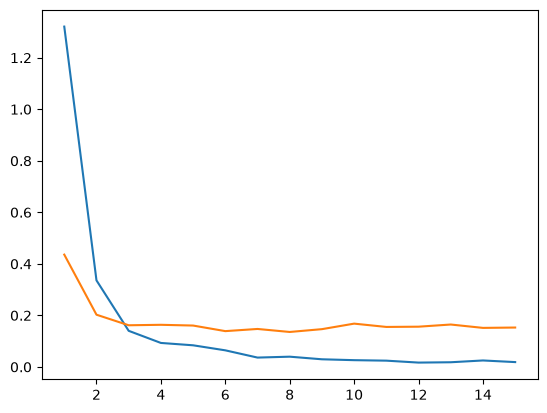

In [34]:
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')

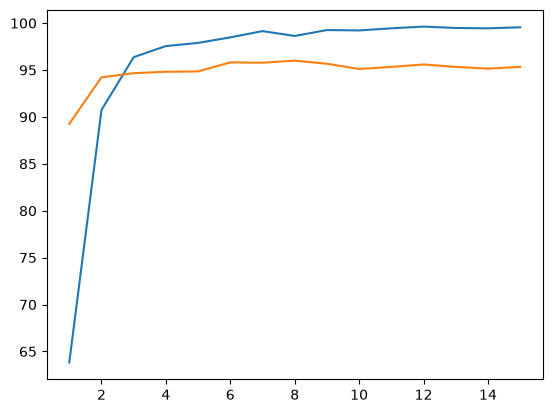

In [41]:
plt.plot(epochs, train_accs, label='Train Loss')
plt.plot(epochs, val_accs, label='Validation Loss')